# Notebook 02: 3D Gaussian Ellipsoid Mathematics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChunLI-666/3DGS-from-scratch/blob/develop/notebooks/phase1/02_3d_gaussian_math.ipynb)

---

## Learning Objectives

By the end of this notebook, you will:
1. Master the mathematical representation of 3D Gaussians
2. Understand covariance matrix decomposition: $\Sigma = RSS^TR^T$
3. Implement quaternion-based rotation
4. Build a complete Gaussian3D class in PyTorch

**Estimated Time**: 60 minutes

**Prerequisites**: Notebook 01 (Gaussian Basics)

---

## Setup

In [ ]:
import os
import sys

# Colab setup
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    if not os.path.exists('3DGS-from-scratch'):
        !git clone https://github.com/ChunLI-666/3DGS-from-scratch.git
    os.chdir('3DGS-from-scratch')
    !pip install -q plotly ipywidgets

# Path setup
for path in ['../../src', '../src', './src']:
    full_path = os.path.abspath(path)
    if os.path.exists(os.path.join(full_path, 'gaussian')):
        sys.path.insert(0, full_path)
        break

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("Setup complete!")

Using device: cuda
Setup complete!


## 1. The 3D Gaussian Formula

A 3D Gaussian is defined by the probability density function:

$$G(\mathbf{x}) = \exp\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\Sigma^{-1}(\mathbf{x}-\boldsymbol{\mu})\right)$$

### Parameters:

| Parameter | Symbol | Shape | Description |
|-----------|--------|-------|-------------|
| Mean | $\boldsymbol{\mu}$ | [3] | Center position (x, y, z) |
| Covariance | $\Sigma$ | [3, 3] | Shape and orientation |

### The Challenge: Ensuring Valid Covariance

The covariance matrix $\Sigma$ must be:
1. **Symmetric**: $\Sigma = \Sigma^T$
2. **Positive Semi-Definite**: All eigenvalues $\geq 0$

If we directly optimize a 3×3 matrix, we might violate these constraints!

## 2. Covariance Decomposition

### The Solution: Parameterize with Scale and Rotation

Instead of optimizing $\Sigma$ directly, 3DGS uses:

$$\Sigma = R \cdot S \cdot S^T \cdot R^T$$

Where:
- $S = \text{diag}(s_x, s_y, s_z)$ is the **scaling matrix**
- $R \in SO(3)$ is the **rotation matrix**

### Why This Works:

1. $S \cdot S^T$ is always positive semi-definite (it's $\text{diag}(s_x^2, s_y^2, s_z^2)$)
2. Rotating a PSD matrix preserves PSD property
3. The result is automatically symmetric

### Geometric Interpretation:

```
Unit Sphere → Scale → Rotate → Ellipsoid
     O      →  S    →   R   →    Σ
```

In [ ]:
def build_covariance_numpy(scaling, rotation_matrix):
    """
    Build covariance matrix from scaling and rotation.
    
    Σ = R @ S @ S.T @ R.T
    
    Args:
        scaling: [3] - scale factors (sx, sy, sz)
        rotation_matrix: [3, 3] - rotation matrix
    
    Returns:
        [3, 3] covariance matrix
    """
    S = np.diag(scaling)
    R = rotation_matrix
    
    # Σ = R @ S @ S.T @ R.T
    # Since S is diagonal, S @ S.T = S^2 = diag(sx^2, sy^2, sz^2)
    S_squared = S @ S.T
    cov = R @ S_squared @ R.T
    
    return cov

# Example
scaling = np.array([2.0, 1.0, 0.5])
R = np.eye(3)  # No rotation

cov = build_covariance_numpy(scaling, R)
print("Scaling:", scaling)
print("\nCovariance (no rotation):")
print(cov)
print("\nNote: Diagonal elements are s^2:", scaling**2)

Scaling: [2.  1.  0.5]

Covariance (no rotation):
[[4.   0.   0.  ]
 [0.   1.   0.  ]
 [0.   0.   0.25]]

Note: Diagonal elements are s^2: [4.   1.   0.25]


In [ ]:
# With rotation
def rotation_matrix_z(theta):
    """Rotation around Z axis by theta radians."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ])

# 45 degree rotation
R = rotation_matrix_z(np.pi / 4)
cov_rotated = build_covariance_numpy(scaling, R)

print("Rotation matrix (45° around Z):")
print(R.round(3))
print("\nCovariance (rotated):")
print(cov_rotated.round(3))
print("\nVerify eigenvalues match scaling^2:")
eigenvalues = np.linalg.eigvalsh(cov_rotated)
print(f"Eigenvalues: {sorted(eigenvalues)}")
print(f"Scaling^2:   {sorted(scaling**2)}")

Rotation matrix (45° around Z):
[[ 0.707 -0.707  0.   ]
 [ 0.707  0.707  0.   ]
 [ 0.     0.     1.   ]]

Covariance (rotated):
[[2.5  1.5  0.  ]
 [1.5  2.5  0.  ]
 [0.   0.   0.25]]

Verify eigenvalues match scaling^2:
Eigenvalues: [np.float64(0.25), np.float64(1.0), np.float64(4.0)]
Scaling^2:   [np.float64(0.25), np.float64(1.0), np.float64(4.0)]


## 3. Quaternions for Rotation

In 3DGS, we use **quaternions** instead of rotation matrices because:

1. **Compact**: 4 parameters vs 9
2. **No Gimbal Lock**: Unlike Euler angles
3. **Easy Normalization**: Just normalize to unit length
4. **Smooth Interpolation**: SLERP

### Quaternion Representation

A quaternion $q = [w, x, y, z]$ where:
- $w$ is the scalar (real) part
- $(x, y, z)$ is the vector (imaginary) part
- $||q|| = 1$ for unit quaternions (representing rotations)

### Quaternion to Rotation Matrix

$$R = \begin{bmatrix}
1-2(y^2+z^2) & 2(xy-wz) & 2(xz+wy) \\
2(xy+wz) & 1-2(x^2+z^2) & 2(yz-wx) \\
2(xz-wy) & 2(yz+wx) & 1-2(x^2+y^2)
\end{bmatrix}$$

In [ ]:
def quaternion_to_rotation_matrix(q):
    """
    Convert quaternion [w, x, y, z] to rotation matrix.
    
    Args:
        q: Quaternion [4] - format [w, x, y, z]
    
    Returns:
        Rotation matrix [3, 3]
    """
    # Normalize quaternion
    q = q / np.linalg.norm(q)
    w, x, y, z = q
    
    # Build rotation matrix
    R = np.array([
        [1 - 2*(y*y + z*z),     2*(x*y - w*z),     2*(x*z + w*y)],
        [    2*(x*y + w*z), 1 - 2*(x*x + z*z),     2*(y*z - w*x)],
        [    2*(x*z - w*y),     2*(y*z + w*x), 1 - 2*(x*x + y*y)]
    ])
    
    return R

# Examples of common quaternions
print("Common Quaternion Examples:")
print("=" * 50)

quaternions = {
    'Identity (no rotation)': [1, 0, 0, 0],
    '90° around X': [np.cos(np.pi/4), np.sin(np.pi/4), 0, 0],
    '90° around Y': [np.cos(np.pi/4), 0, np.sin(np.pi/4), 0],
    '90° around Z': [np.cos(np.pi/4), 0, 0, np.sin(np.pi/4)],
    '180° around Z': [0, 0, 0, 1],
}

for name, q in quaternions.items():
    R = quaternion_to_rotation_matrix(np.array(q))
    print(f"\n{name}:")
    print(f"  q = {q}")
    print(f"  R = \n{R.round(3)}")

Common Quaternion Examples:

Identity (no rotation):
  q = [1, 0, 0, 0]
  R = 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

90° around X:
  q = [np.float64(0.7071067811865476), np.float64(0.7071067811865475), 0, 0]
  R = 
[[ 1.  0.  0.]
 [ 0.  0. -1.]
 [ 0.  1.  0.]]

90° around Y:
  q = [np.float64(0.7071067811865476), 0, np.float64(0.7071067811865475), 0]
  R = 
[[ 0.  0.  1.]
 [ 0.  1.  0.]
 [-1.  0.  0.]]

90° around Z:
  q = [np.float64(0.7071067811865476), 0, 0, np.float64(0.7071067811865475)]
  R = 
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

180° around Z:
  q = [0, 0, 0, 1]
  R = 
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]


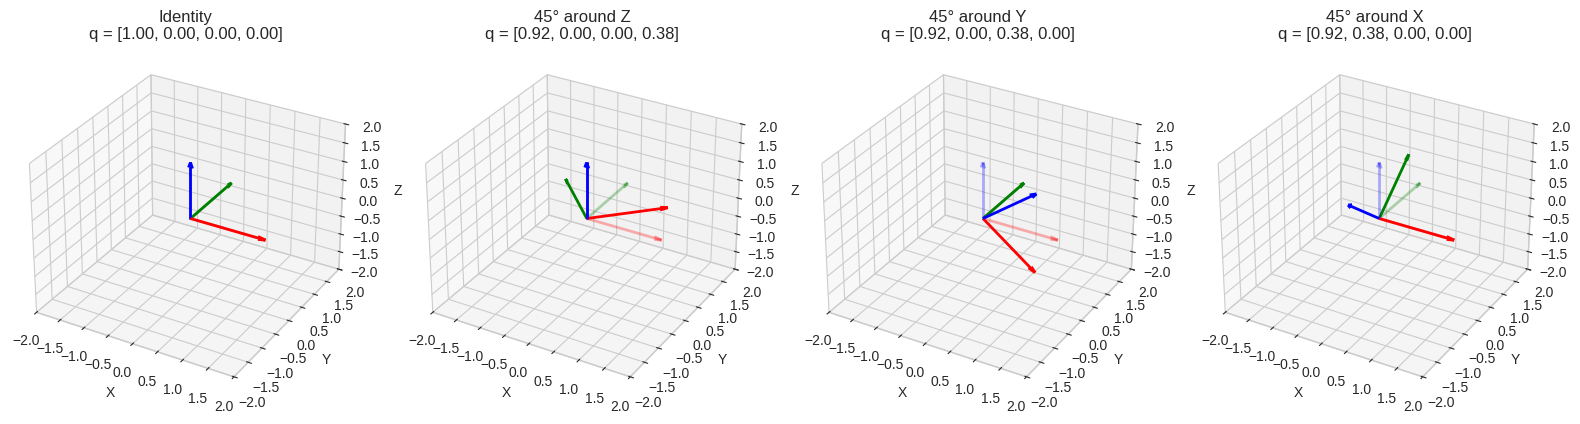

In [ ]:
# Visualize quaternion rotations
fig = plt.figure(figsize=(16, 4))

# Helper to plot coordinate axes
def plot_axes(ax, R, origin=[0,0,0], length=1.5, alpha=1.0):
    colors = ['red', 'green', 'blue']
    labels = ['X', 'Y', 'Z']
    for i in range(3):
        direction = R[:, i] * length
        ax.quiver(*origin, *direction, color=colors[i], 
                  arrow_length_ratio=0.1, linewidth=2, alpha=alpha)

quaternion_demos = [
    ('Identity', [1, 0, 0, 0]),
    ('45° around Z', [np.cos(np.pi/8), 0, 0, np.sin(np.pi/8)]),
    ('45° around Y', [np.cos(np.pi/8), 0, np.sin(np.pi/8), 0]),
    ('45° around X', [np.cos(np.pi/8), np.sin(np.pi/8), 0, 0]),
]

for i, (name, q) in enumerate(quaternion_demos):
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    R = quaternion_to_rotation_matrix(np.array(q))
    
    # Plot original axes (faded)
    plot_axes(ax, np.eye(3), alpha=0.3)
    
    # Plot rotated axes
    plot_axes(ax, R, alpha=1.0)
    
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_zlim(-2, 2)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'{name}\nq = [{q[0]:.2f}, {q[1]:.2f}, {q[2]:.2f}, {q[3]:.2f}]')

plt.tight_layout()
plt.show()

## 4. PyTorch Implementation

Now let's implement everything in PyTorch with gradient support.

In [ ]:
def quaternion_to_rotation_matrix_torch(q):
    """
    Convert quaternion to rotation matrix (PyTorch version).
    
    Args:
        q: Quaternion [4] or [N, 4] in [w, x, y, z] format
    
    Returns:
        Rotation matrix [3, 3] or [N, 3, 3]
    """
    if q.dim() == 1:
        q = q.unsqueeze(0)
        squeeze = True
    else:
        squeeze = False
    
    # Normalize
    q = q / (q.norm(dim=-1, keepdim=True) + 1e-8)
    
    w, x, y, z = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
    
    # Compute rotation matrix elements
    R = torch.zeros(q.shape[0], 3, 3, device=q.device, dtype=q.dtype)
    
    R[:, 0, 0] = 1 - 2*(y*y + z*z)
    R[:, 0, 1] = 2*(x*y - w*z)
    R[:, 0, 2] = 2*(x*z + w*y)
    
    R[:, 1, 0] = 2*(x*y + w*z)
    R[:, 1, 1] = 1 - 2*(x*x + z*z)
    R[:, 1, 2] = 2*(y*z - w*x)
    
    R[:, 2, 0] = 2*(x*z - w*y)
    R[:, 2, 1] = 2*(y*z + w*x)
    R[:, 2, 2] = 1 - 2*(x*x + y*y)
    
    if squeeze:
        R = R.squeeze(0)
    
    return R


def build_covariance_torch(scaling, rotation_quat):
    """
    Build covariance matrix from scaling and rotation quaternion.
    
    Σ = R @ S @ S.T @ R.T
    
    Args:
        scaling: [3] or [N, 3] - scale factors
        rotation_quat: [4] or [N, 4] - quaternion [w, x, y, z]
    
    Returns:
        Covariance matrix [3, 3] or [N, 3, 3]
    """
    if scaling.dim() == 1:
        scaling = scaling.unsqueeze(0)
        rotation_quat = rotation_quat.unsqueeze(0)
        squeeze = True
    else:
        squeeze = False
    
    batch_size = scaling.shape[0]
    device = scaling.device
    dtype = scaling.dtype
    
    # Get rotation matrix
    R = quaternion_to_rotation_matrix_torch(rotation_quat)  # [N, 3, 3]
    
    # Build diagonal scaling matrix S^2
    S_squared = torch.zeros(batch_size, 3, 3, device=device, dtype=dtype)
    S_squared[:, 0, 0] = scaling[:, 0] ** 2
    S_squared[:, 1, 1] = scaling[:, 1] ** 2
    S_squared[:, 2, 2] = scaling[:, 2] ** 2
    
    # Compute covariance: Σ = R @ S^2 @ R.T
    cov = R @ S_squared @ R.transpose(-1, -2)
    
    if squeeze:
        cov = cov.squeeze(0)
    
    return cov


# Test the implementation
print("Testing PyTorch Implementation")
print("=" * 50)

scaling = torch.tensor([2.0, 1.0, 0.5])
quat = torch.tensor([1.0, 0.0, 0.0, 0.0])  # Identity

cov = build_covariance_torch(scaling, quat)
print(f"Scaling: {scaling}")
print(f"Quaternion: {quat}")
print(f"\nCovariance matrix:")
print(cov)

# Verify with rotation
angle = np.pi / 4  # 45 degrees
quat_rot = torch.tensor([np.cos(angle/2), 0, 0, np.sin(angle/2)], dtype=torch.float32)  # Around Z
cov_rot = build_covariance_torch(scaling, quat_rot)

print(f"\nWith 45° rotation around Z:")
print(cov_rot)

## 5. Complete Gaussian3D Class

Now let's build a complete, differentiable Gaussian3D class.

In [ ]:
class Gaussian3D:
    """
    A 3D Gaussian primitive for 3D Gaussian Splatting.
    
    Parameterized by:
    - mean: Center position [3]
    - scaling: Scale factors [3] (in log space for optimization)
    - rotation: Quaternion [4] in [w, x, y, z] format
    - opacity: Opacity value [1] (in logit space for optimization)
    - color: RGB color [3] or SH coefficients
    """
    
    def __init__(self, mean, scaling, rotation, opacity=0.5, color=None):
        """
        Initialize a 3D Gaussian.
        
        Args:
            mean: [3] - center position
            scaling: [3] - scale factors (actual values, not log)
            rotation: [4] - quaternion [w, x, y, z]
            opacity: float - opacity (0-1)
            color: [3] - RGB color (optional)
        """
        self.mean = torch.as_tensor(mean, dtype=torch.float32)
        
        # Store scaling in log space for unconstrained optimization
        self._scaling = torch.log(torch.as_tensor(scaling, dtype=torch.float32))
        
        # Normalize quaternion
        rotation = torch.as_tensor(rotation, dtype=torch.float32)
        self._rotation = rotation / rotation.norm()
        
        # Store opacity in logit space for unconstrained optimization
        opacity = torch.tensor([opacity], dtype=torch.float32)
        self._opacity = torch.log(opacity / (1 - opacity))  # logit
        
        if color is not None:
            self.color = torch.as_tensor(color, dtype=torch.float32)
        else:
            self.color = torch.tensor([0.5, 0.5, 0.5], dtype=torch.float32)
    
    @property
    def scaling(self):
        """Get scaling (exp of stored values)."""
        return torch.exp(self._scaling)
    
    @property
    def rotation(self):
        """Get normalized rotation quaternion."""
        return self._rotation / self._rotation.norm()
    
    @property
    def opacity(self):
        """Get opacity (sigmoid of stored value)."""
        return torch.sigmoid(self._opacity)
    
    def get_covariance(self):
        """Compute the 3D covariance matrix."""
        return build_covariance_torch(self.scaling, self.rotation)
    
    def get_rotation_matrix(self):
        """Get the rotation matrix from quaternion."""
        return quaternion_to_rotation_matrix_torch(self.rotation)
    
    def evaluate(self, points):
        """
        Evaluate the Gaussian at given 3D points.
        
        Args:
            points: [N, 3] - 3D points
        
        Returns:
            [N] - Gaussian values at each point
        """
        cov = self.get_covariance()
        cov_inv = torch.linalg.inv(cov)
        
        diff = points - self.mean  # [N, 3]
        
        # Mahalanobis distance: (x-μ)^T Σ^(-1) (x-μ)
        mahal = torch.einsum('ni,ij,nj->n', diff, cov_inv, diff)
        
        return torch.exp(-0.5 * mahal)
    
    def __repr__(self):
        return (f"Gaussian3D(\n"
                f"  mean={self.mean.tolist()},\n"
                f"  scaling={self.scaling.tolist()},\n"
                f"  rotation={self.rotation.tolist()},\n"
                f"  opacity={self.opacity.item():.3f},\n"
                f"  color={self.color.tolist()}\n"
                f")")


# Create a Gaussian
g = Gaussian3D(
    mean=[0, 0, 0],
    scaling=[1.0, 0.5, 0.3],
    rotation=[1, 0, 0, 0],  # Identity
    opacity=0.8,
    color=[1.0, 0.0, 0.0]  # Red
)

print(g)
print("\nCovariance matrix:")
print(g.get_covariance())

In [ ]:
# Evaluate the Gaussian at some points
test_points = torch.tensor([
    [0, 0, 0],      # At center
    [1, 0, 0],      # 1 unit along X
    [0, 1, 0],      # 1 unit along Y
    [0, 0, 1],      # 1 unit along Z
    [0.5, 0.25, 0.15],  # Somewhere inside
], dtype=torch.float32)

values = g.evaluate(test_points)

print("Gaussian values at test points:")
print("=" * 50)
for point, value in zip(test_points, values):
    print(f"  {point.tolist()} -> {value.item():.4f}")

print("\nNote: Value at center is 1.0 (maximum)")
print("Value decreases with distance from center,")
print("faster along axes with smaller scaling.")

## 6. Visualization: 3D Gaussian Ellipsoid

In [ ]:
def plot_gaussian_ellipsoid(ax, gaussian, n_std=2, resolution=20, alpha=0.4):
    """
    Plot a Gaussian3D as an ellipsoid.
    
    Args:
        ax: Matplotlib 3D axes
        gaussian: Gaussian3D instance
        n_std: Number of standard deviations
        resolution: Surface resolution
        alpha: Transparency
    """
    mean = gaussian.mean.numpy()
    cov = gaussian.get_covariance().numpy()
    color = gaussian.color.numpy()
    
    # Eigendecomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    # Create unit sphere
    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    
    # Transform to ellipsoid
    radii = n_std * np.sqrt(eigenvalues)
    sphere = np.stack([x, y, z], axis=-1)
    ellipsoid = np.einsum('ij,klj->kli', eigenvectors @ np.diag(radii), sphere) + mean
    
    # Plot
    ax.plot_surface(
        ellipsoid[:, :, 0],
        ellipsoid[:, :, 1],
        ellipsoid[:, :, 2],
        color=color, alpha=alpha * gaussian.opacity.item()
    )
    
    # Center point
    ax.scatter(*mean, color=color, s=50)


# Create multiple Gaussians with different parameters
gaussians = [
    Gaussian3D([0, 0, 0], [1, 0.5, 0.3], [1, 0, 0, 0], 0.9, [1, 0, 0]),  # Red
    Gaussian3D([2, 0, 0], [0.5, 0.5, 0.5], [1, 0, 0, 0], 0.7, [0, 1, 0]),  # Green
    Gaussian3D([0, 2, 0], [0.8, 0.3, 0.6], 
               [np.cos(np.pi/8), 0, 0, np.sin(np.pi/8)], 0.8, [0, 0, 1]),  # Blue, rotated
    Gaussian3D([1, 1, 1], [0.4, 0.4, 1.0],
               [np.cos(np.pi/6), np.sin(np.pi/6), 0, 0], 0.6, [1, 1, 0]),  # Yellow, rotated
]

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

for g in gaussians:
    plot_gaussian_ellipsoid(ax, g, n_std=2, alpha=0.5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Multiple 3D Gaussians with Different Parameters')

# Equal aspect ratio
ax.set_xlim(-2, 4)
ax.set_ylim(-2, 4)
ax.set_zlim(-2, 4)

plt.tight_layout()
plt.show()

## 7. Gradient Flow Verification

Let's verify that gradients flow correctly through our implementation.

In [ ]:
# Create parameters with gradient tracking
mean = torch.tensor([0.0, 0.0, 0.0], requires_grad=True)
scaling_raw = torch.tensor([0.0, -0.69, -1.2], requires_grad=True)  # log scale
rotation_raw = torch.tensor([1.0, 0.0, 0.0, 0.0], requires_grad=True)

def forward(mean, scaling_raw, rotation_raw, target_point):
    """
    Forward pass: compute Gaussian value at target point.
    """
    # Activate parameters
    scaling = torch.exp(scaling_raw)
    rotation = rotation_raw / rotation_raw.norm()
    
    # Build covariance
    cov = build_covariance_torch(scaling, rotation)
    cov_inv = torch.linalg.inv(cov)
    
    # Evaluate Gaussian
    diff = target_point - mean
    mahal = diff @ cov_inv @ diff
    value = torch.exp(-0.5 * mahal)
    
    return value

# Target: we want high Gaussian value at point [1, 0.5, 0.2]
target = torch.tensor([1.0, 0.5, 0.2])

# Forward pass
value = forward(mean, scaling_raw, rotation_raw, target)
print(f"Initial Gaussian value at target: {value.item():.4f}")

# Backward pass
loss = -value  # Maximize value = minimize negative
loss.backward()

print(f"\nGradients:")
print(f"  d(loss)/d(mean) = {mean.grad}")
print(f"  d(loss)/d(scaling_raw) = {scaling_raw.grad}")
print(f"  d(loss)/d(rotation_raw) = {rotation_raw.grad}")

print("\nInterpretation:")
print("- Mean gradient points toward target (to increase value)")
print("- Scaling gradient suggests enlarging the Gaussian")
print("- Rotation gradient suggests orienting toward target")

In [ ]:
# Simple optimization demo
mean = torch.tensor([0.0, 0.0, 0.0], requires_grad=True)
scaling_raw = torch.tensor([0.0, 0.0, 0.0], requires_grad=True)
rotation_raw = torch.tensor([1.0, 0.0, 0.0, 0.0], requires_grad=True)

optimizer = torch.optim.Adam([mean, scaling_raw, rotation_raw], lr=0.1)
target = torch.tensor([1.0, 0.5, 0.2])

print("Optimizing Gaussian to maximize value at target...")
print("=" * 50)

losses = []
for step in range(50):
    optimizer.zero_grad()
    
    value = forward(mean, scaling_raw, rotation_raw, target)
    loss = -value
    
    loss.backward()
    optimizer.step()
    
    losses.append(-loss.item())
    
    if step % 10 == 0:
        print(f"Step {step:3d}: value = {value.item():.4f}, mean = {mean.data.tolist()}")

print(f"\nFinal:")
print(f"  Mean: {mean.data.tolist()}")
print(f"  Scaling: {torch.exp(scaling_raw).data.tolist()}")
print(f"  Target was: {target.tolist()}")

# Plot optimization progress
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Gaussian Value at Target')
plt.title('Optimization Progress')
plt.grid(True, alpha=0.3)
plt.show()

## 8. Summary: 3D Gaussian Parameters

### Parameter Summary

| Parameter | Stored | Activated | Purpose |
|-----------|--------|-----------|--------|
| Position | $\mu$ | $\mu$ | Center location |
| Scaling | $\log(s)$ | $\exp(\log(s)) = s$ | Ellipsoid size |
| Rotation | $q$ | $q / ||q||$ | Ellipsoid orientation |
| Opacity | $\text{logit}(\alpha)$ | $\sigma(\text{logit}) = \alpha$ | Transparency |

### Key Formulas

1. **Covariance from parameters:**
   $$\Sigma = R(q) \cdot \text{diag}(s)^2 \cdot R(q)^T$$

2. **Gaussian evaluation:**
   $$G(x) = \exp\left(-\frac{1}{2}(x-\mu)^T\Sigma^{-1}(x-\mu)\right)$$

3. **Quaternion to rotation:**
   $$R_{ij} = f(w, x, y, z)$$ (see implementation above)

---

## Key Takeaways

1. **Covariance decomposition** ensures valid positive semi-definite matrices
2. **Quaternions** provide compact, singularity-free rotation representation
3. **Log/logit space** allows unconstrained optimization of scale and opacity
4. **Gradients flow** correctly for end-to-end optimization

---

## Next Steps

In the next notebook, we'll learn how to **project** these 3D Gaussians onto a 2D image plane:

**[03_projection_splatting.ipynb](./03_projection_splatting.ipynb)** - Projection and Splatting